<a href="https://colab.research.google.com/github/shbhm96/Case_study_Minkowski_Decision_Tree/blob/main/Case_Study_Minkowski.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [7]:
data = pd.read_csv('/content/sample_data/online_education.csv')

In [8]:
data.head()

,Education Level,Institution Type,Gender,Age,Device,IT Student,Location,Financial Condition,Internet Type,Network Type,Flexibility Level
0,University,Private,Male,23,Tab,No,Town,Mid,Wifi,4G,Moderate
1,University,Private,Female,23,Mobile,No,Town,Mid,Mobile Data,4G,Moderate
2,College,Public,Female,18,Mobile,No,Town,Mid,Wifi,4G,Moderate
3,School,Private,Female,11,Mobile,No,Town,Mid,Mobile Data,4G,Moderate
4,School,Private,Female,18,Mobile,No,Town,Poor,Mobile Data,3G,Low


In [9]:
data.tail()

,Education Level,Institution Type,Gender,Age,Device,IT Student,Location,Financial Condition,Internet Type,Network Type,Flexibility Level
1200,College,Private,Female,18,Mobile,No,Town,Mid,Wifi,4G,Low
1201,College,Private,Female,18,Mobile,No,Rural,Mid,Wifi,4G,Moderate
1202,School,Private,Male,11,Mobile,No,Town,Mid,Mobile Data,3G,Moderate
1203,College,Private,Female,18,Mobile,No,Rural,Mid,Wifi,4G,Low
1204,School,Private,Female,11,Mobile,No,Town,Poor,Mobile Data,3G,Moderate


In [10]:
data.shape

(1205, 11)

In [11]:
data.columns

Index(['Education Level', 'Institution Type', 'Gender', 'Age', 'Device',
       'IT Student', 'Location', 'Financial Condition', 'Internet Type',
       'Network Type', 'Flexibility Level'],
      dtype='object')

In [12]:
data.duplicated().sum()

np.int64(980)

In [13]:
data.isnull().sum()

,0
Education Level,0
Institution Type,0
Gender,0
Age,0
Device,0
IT Student,0
Location,0
Financial Condition,0
Internet Type,0
Network Type,0


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Education Level      1205 non-null   object
 1   Institution Type     1205 non-null   object
 2   Gender               1205 non-null   object
 3   Age                  1205 non-null   int64 
 4   Device               1205 non-null   object
 5   IT Student           1205 non-null   object
 6   Location             1205 non-null   object
 7   Financial Condition  1205 non-null   object
 8   Internet Type        1205 non-null   object
 9   Network Type         1205 non-null   object
 10  Flexibility Level    1205 non-null   object
dtypes: int64(1), object(10)
memory usage: 103.7+ KB


In [15]:
data.describe()

,Age
count,1205.000000
mean,17.065560
std,5.830369
min,9.000000
25%,11.000000
50%,18.000000
75%,23.000000
max,27.000000


In [16]:
data.nunique()

,0
Education Level,3
Institution Type,2
Gender,2
Age,6
Device,3
IT Student,2
Location,2
Financial Condition,3
Internet Type,2
Network Type,3


In [17]:
data.describe()

,Age
count,1205.000000
mean,17.065560
std,5.830369
min,9.000000
25%,11.000000
50%,18.000000
75%,23.000000
max,27.000000


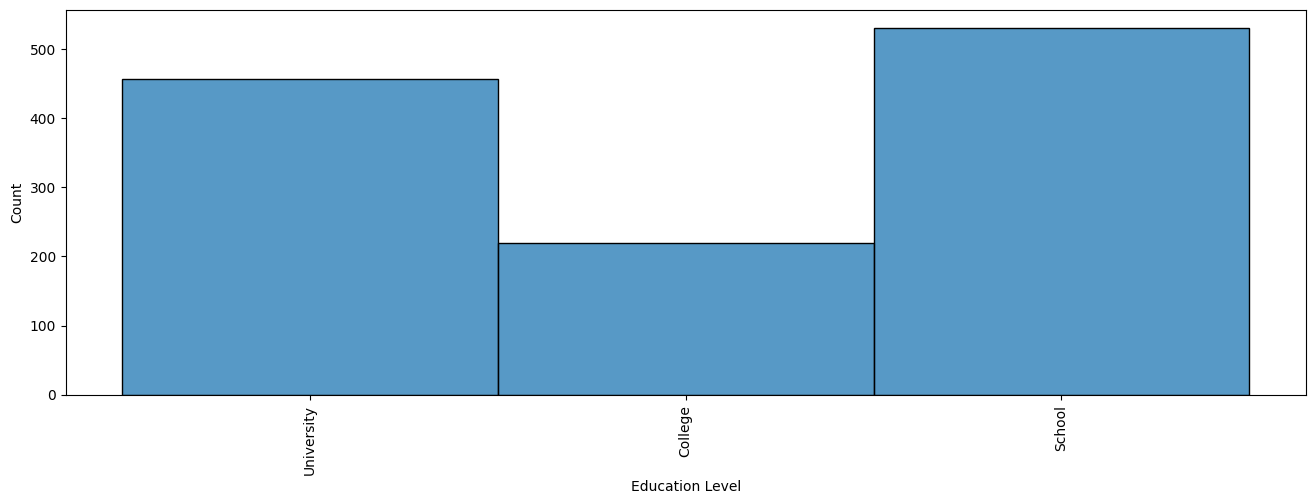

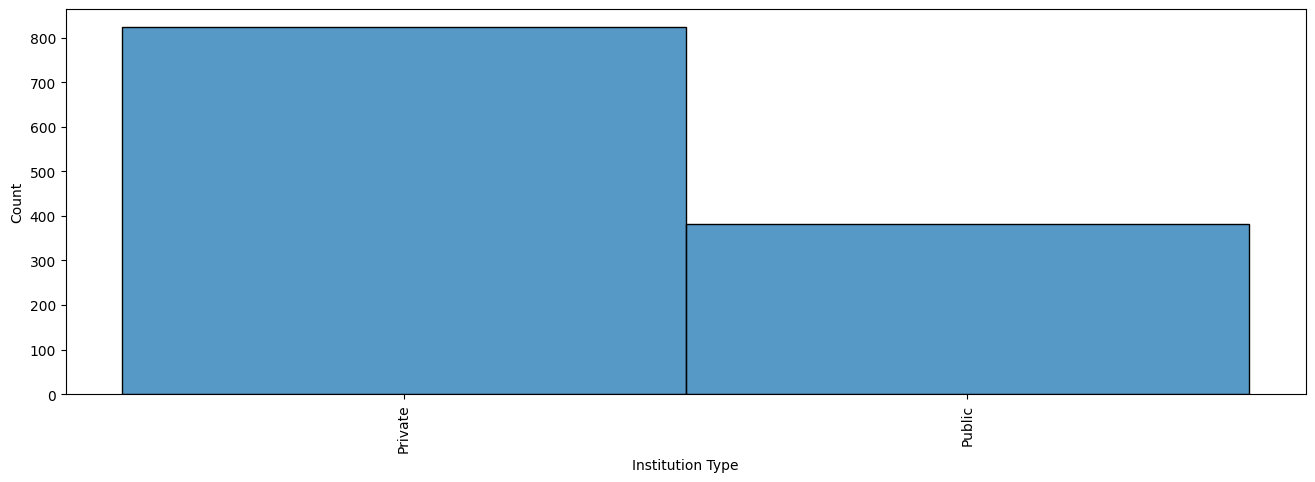

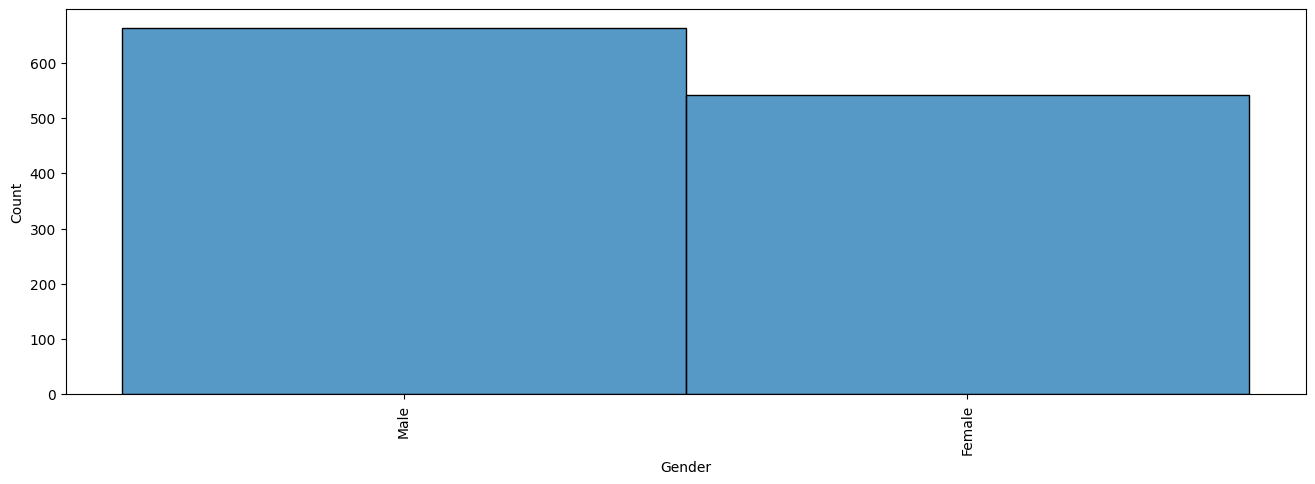

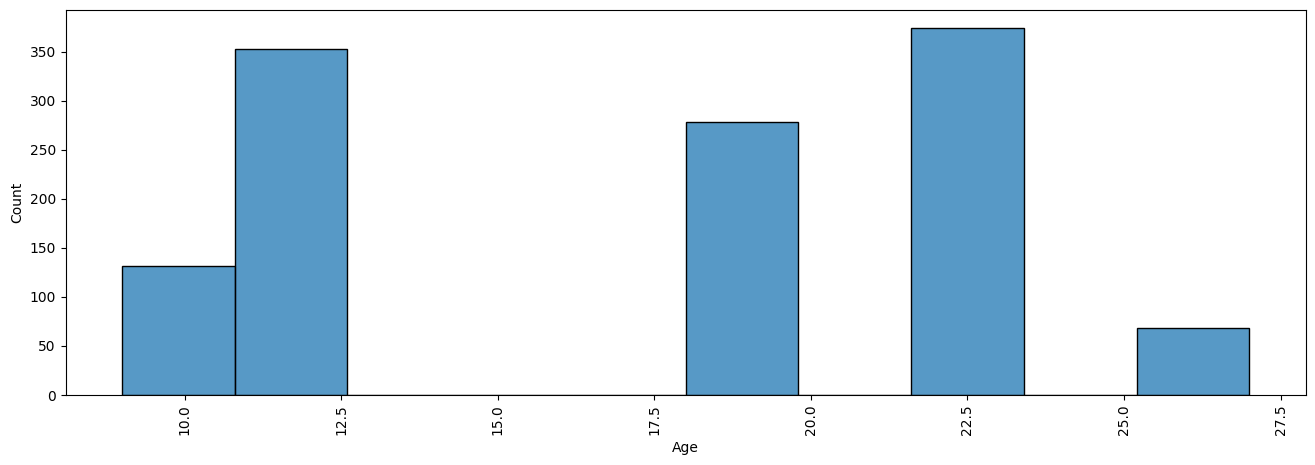

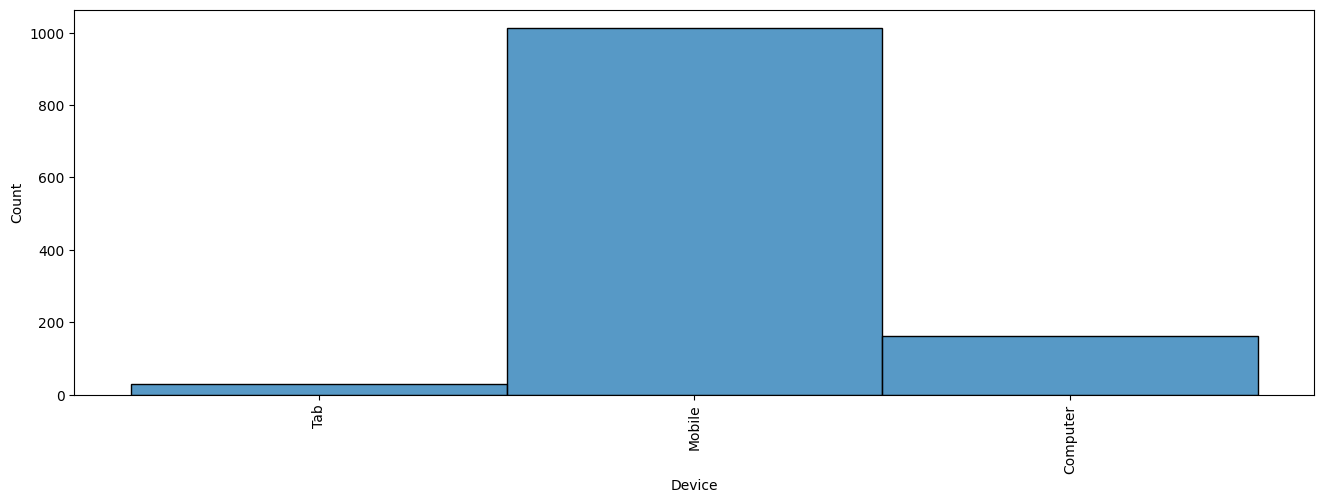

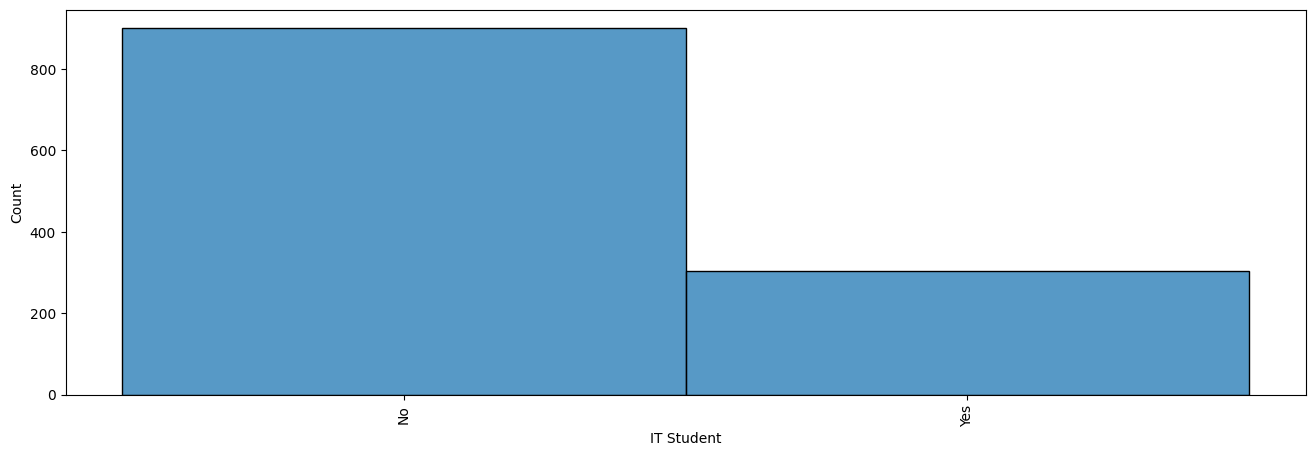

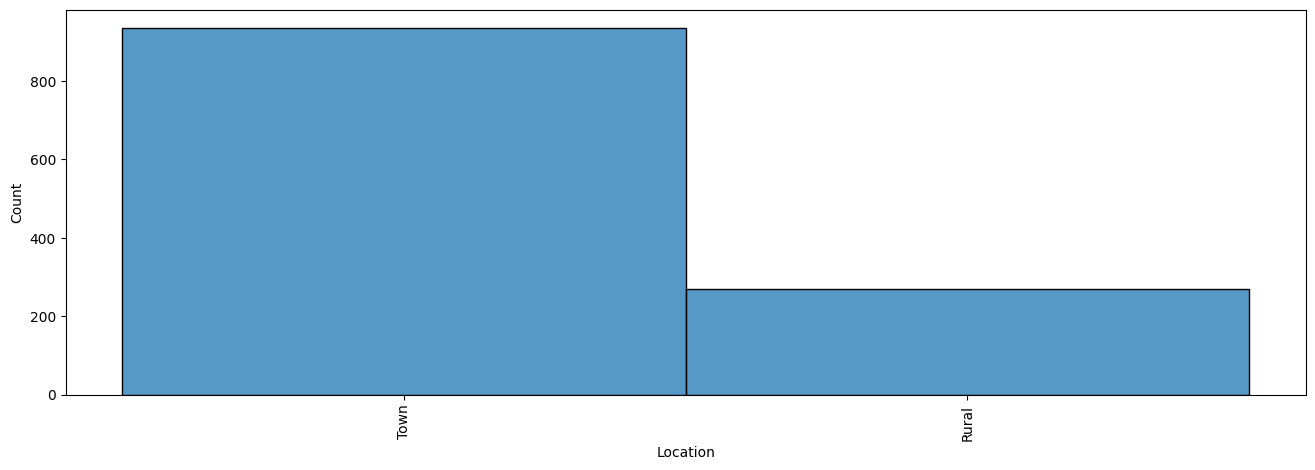

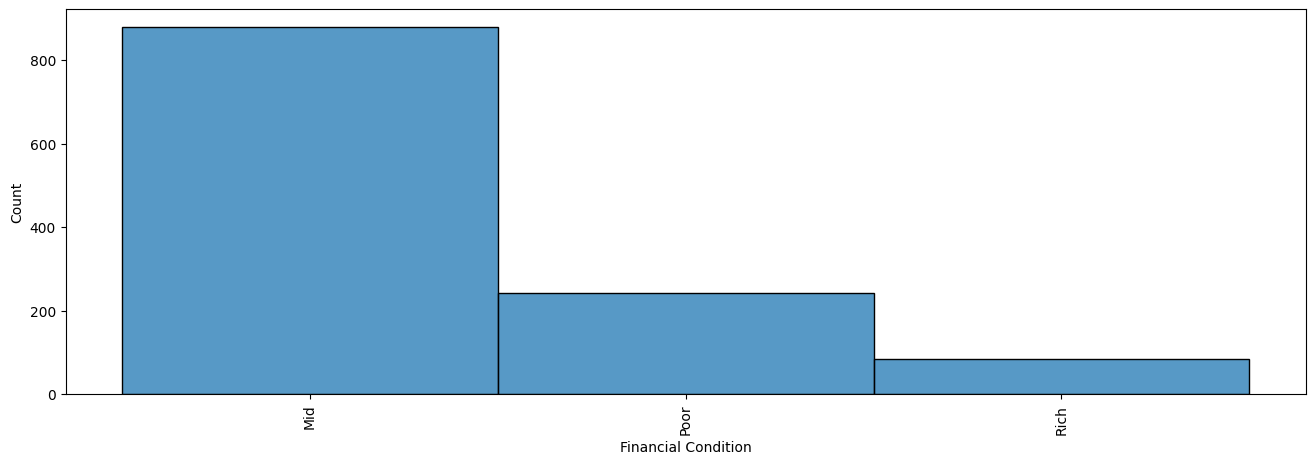

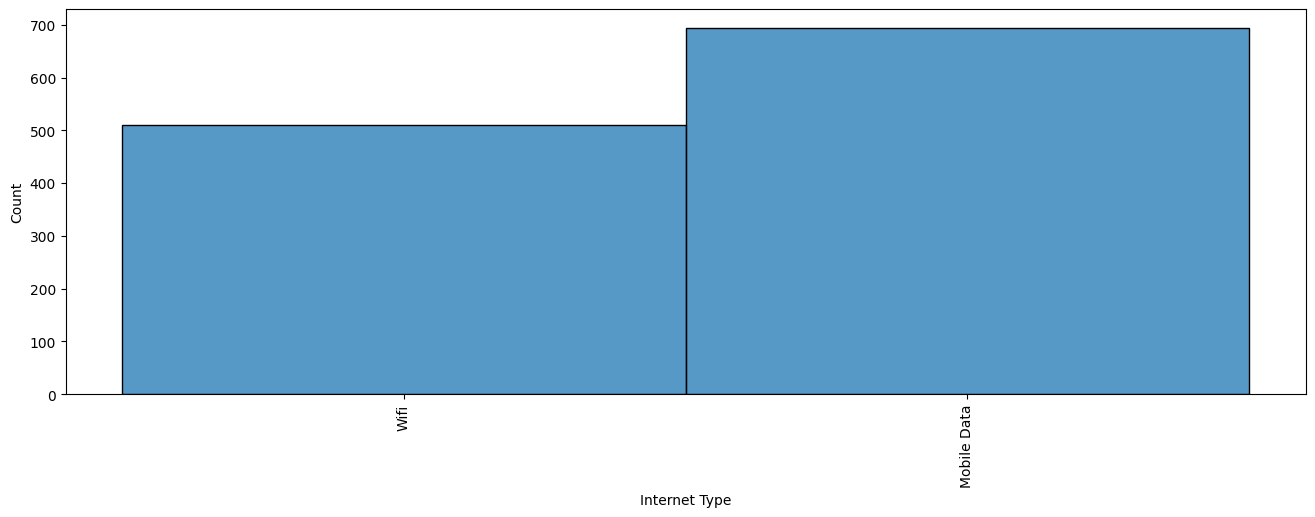

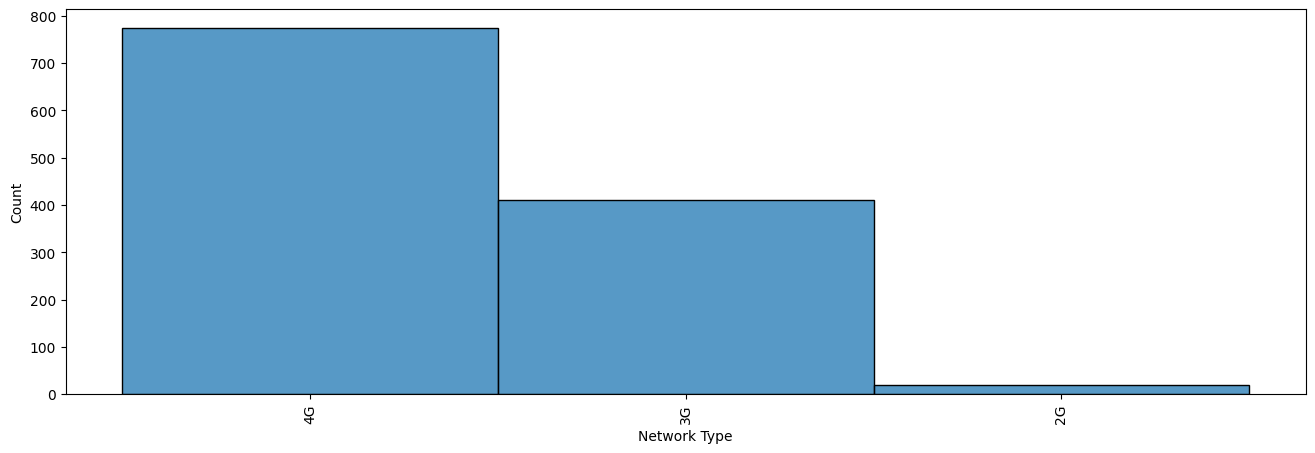

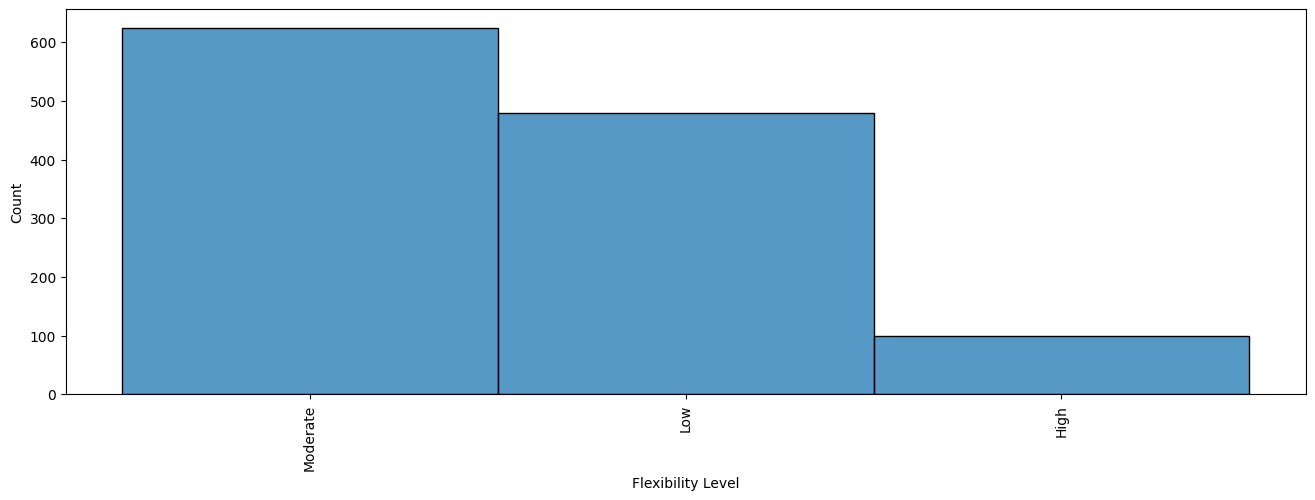

In [18]:
for i in data.columns:
  plt.figure(figsize=(16,5))
  sns.histplot(data[i], bins = 10)
  plt.xticks(rotation=90)
  plt.show()

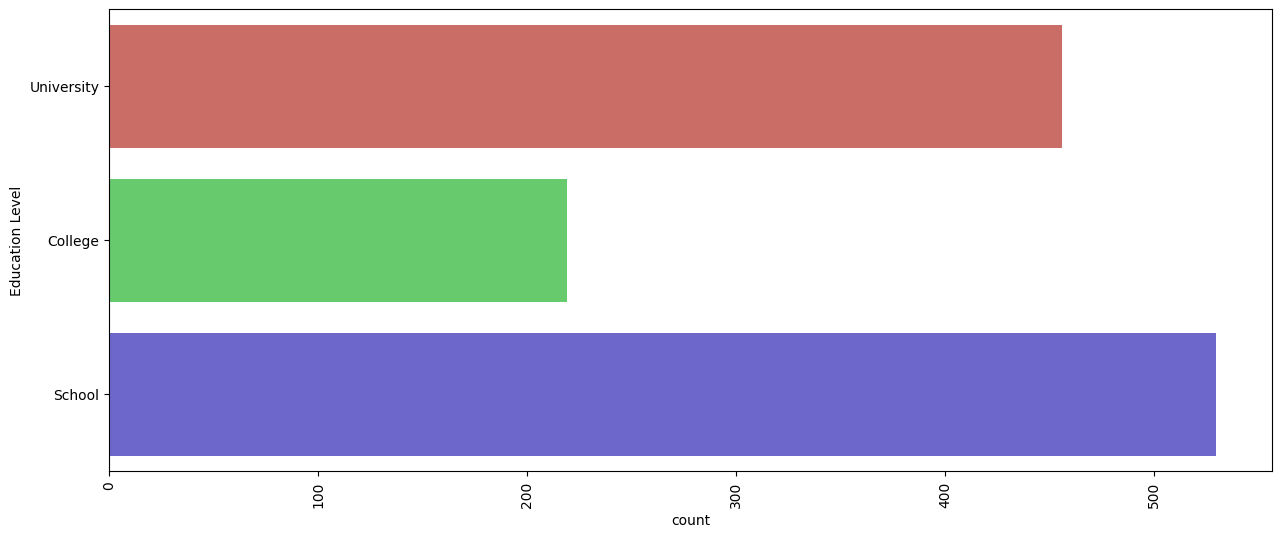

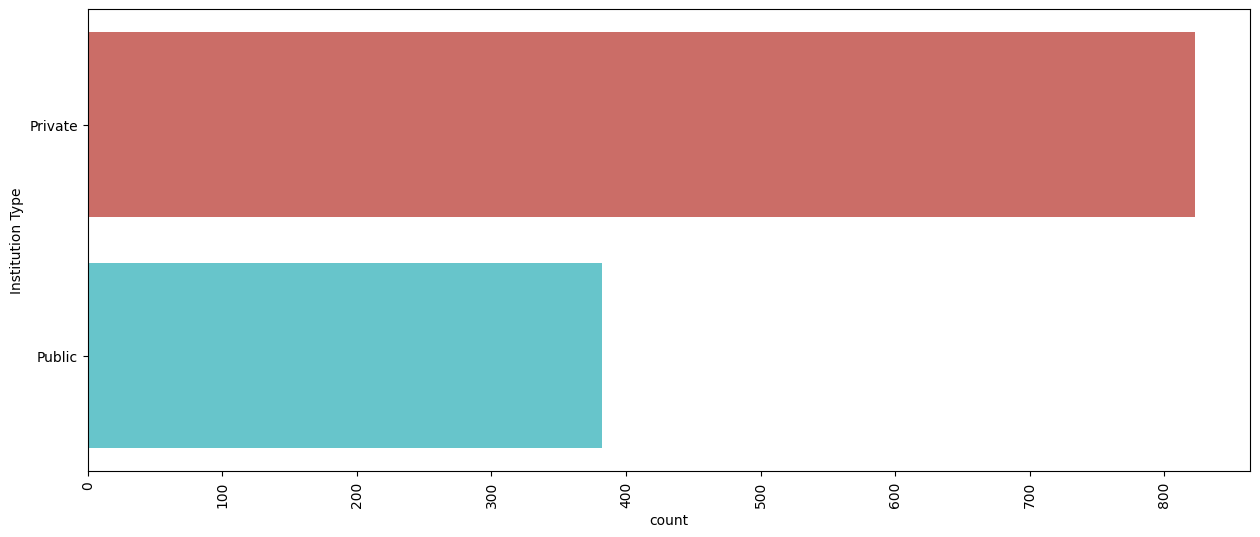

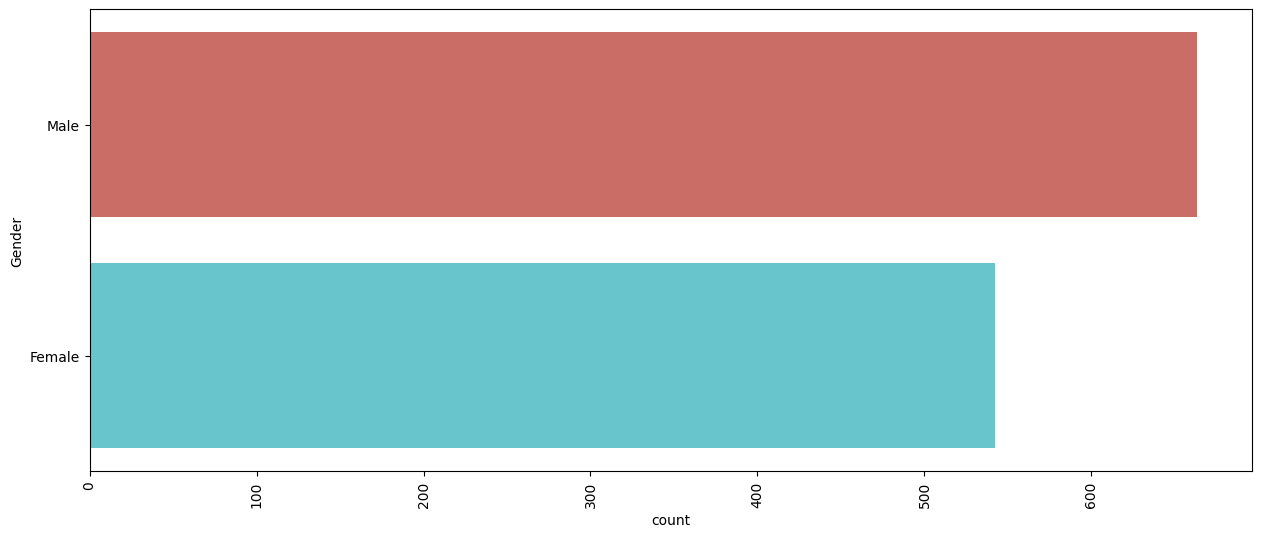

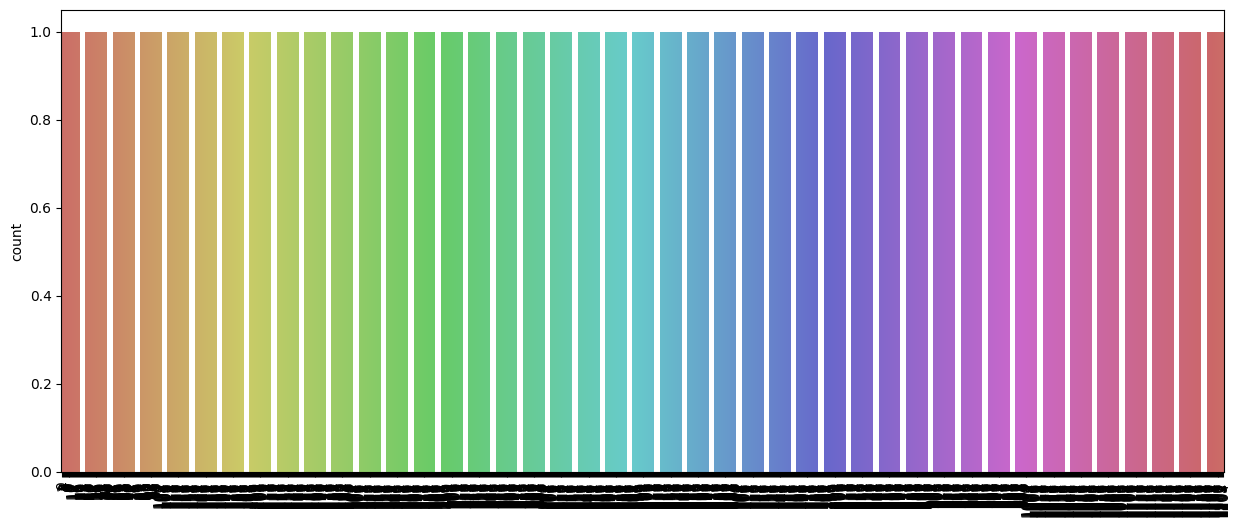

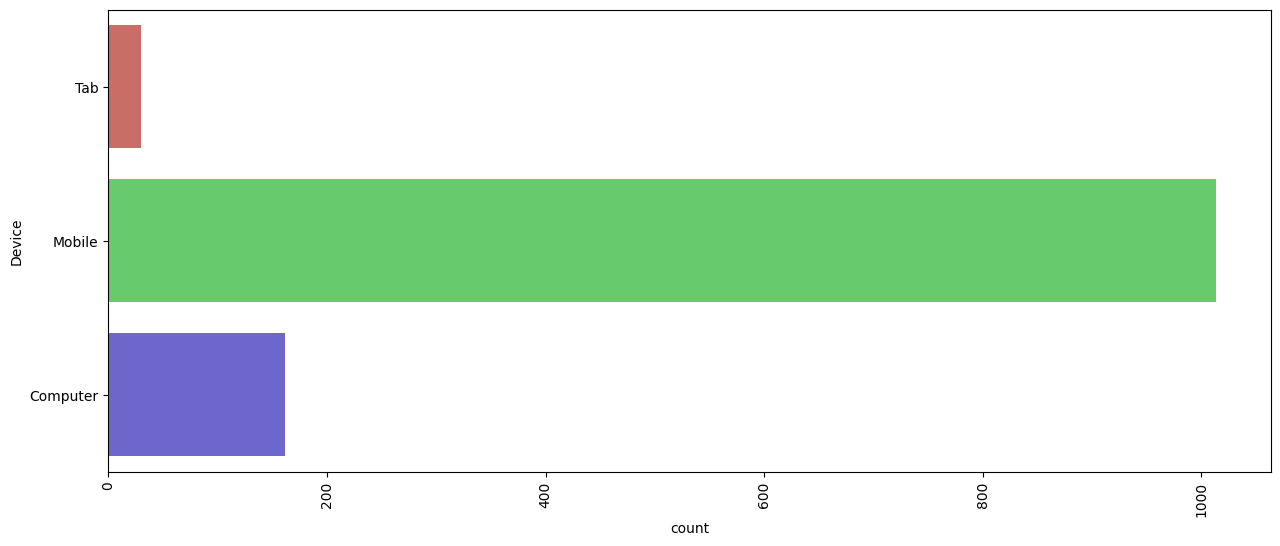

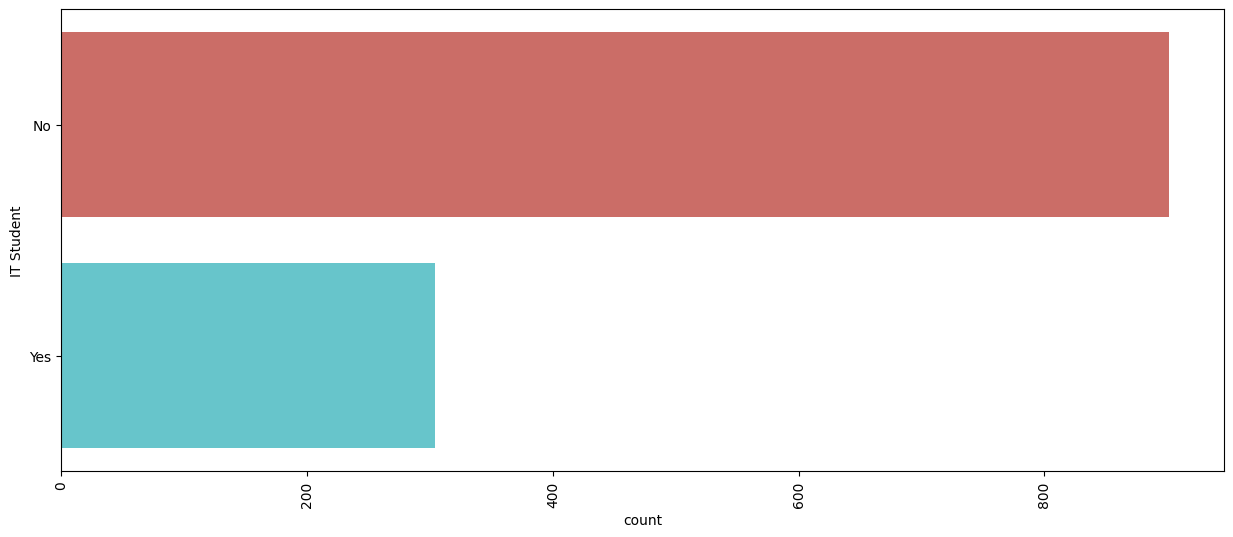

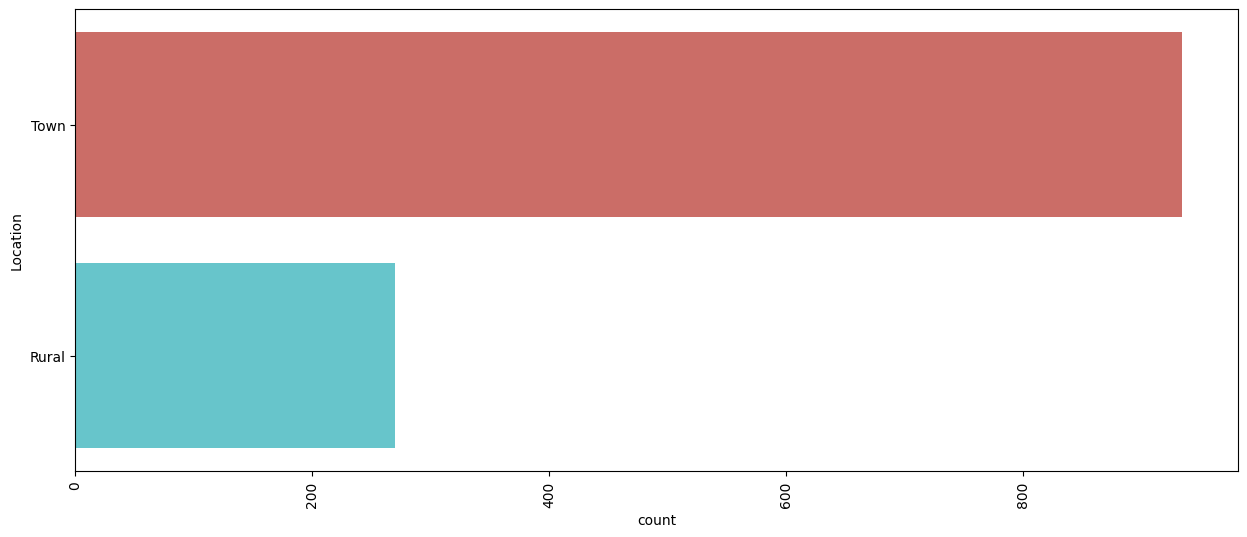

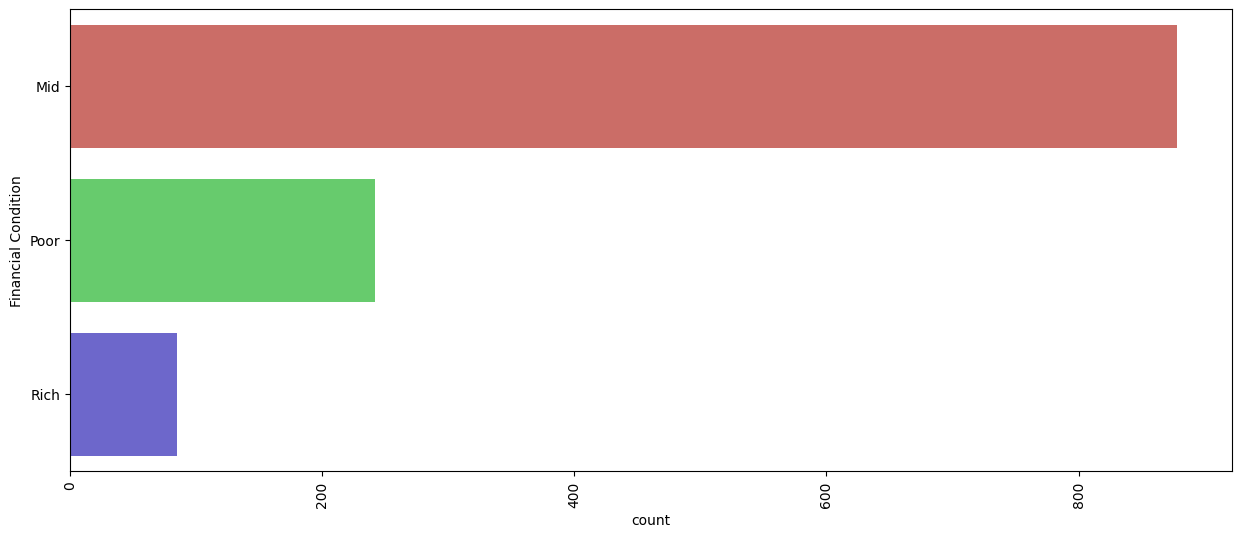

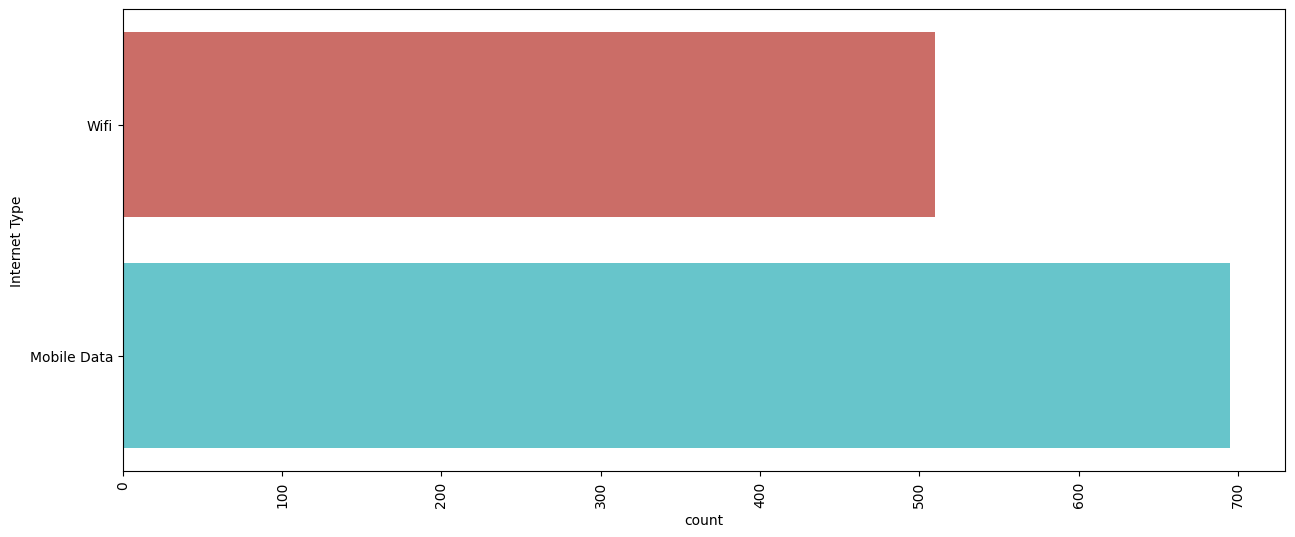

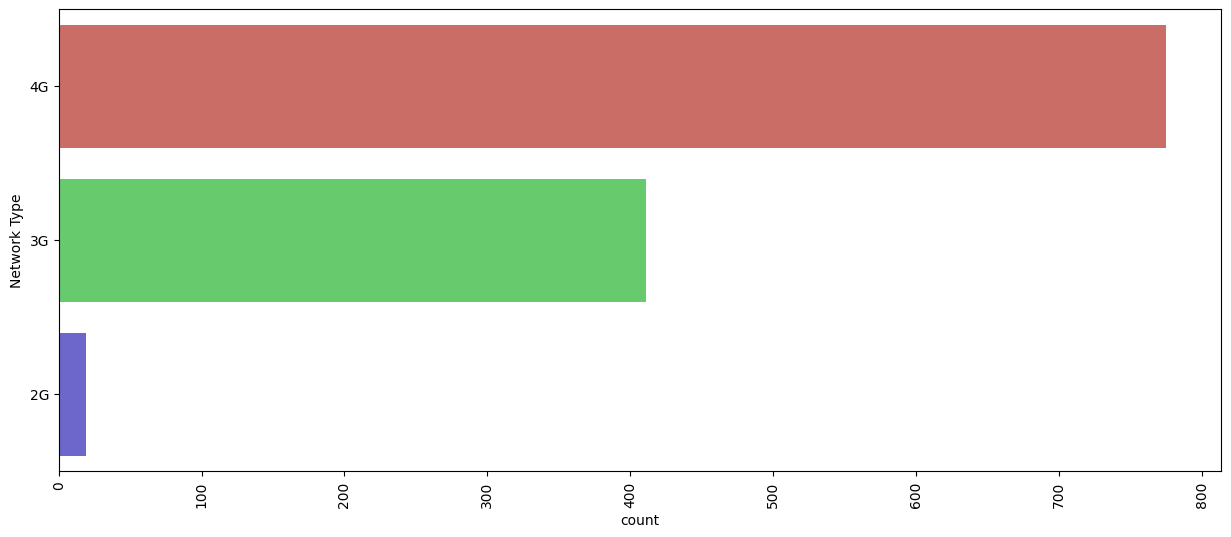

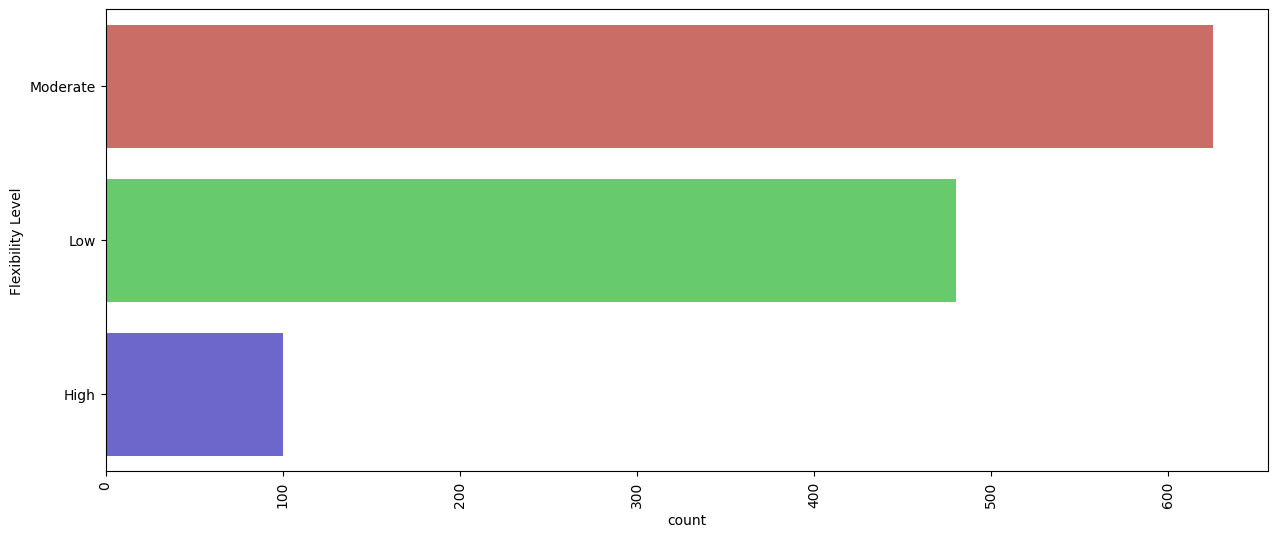

In [25]:
for i in data.columns:
  plt.figure(figsize=(15,6))
  sns.countplot(data[i], palette='hls')
  plt.xticks(rotation=90)
  plt.show()

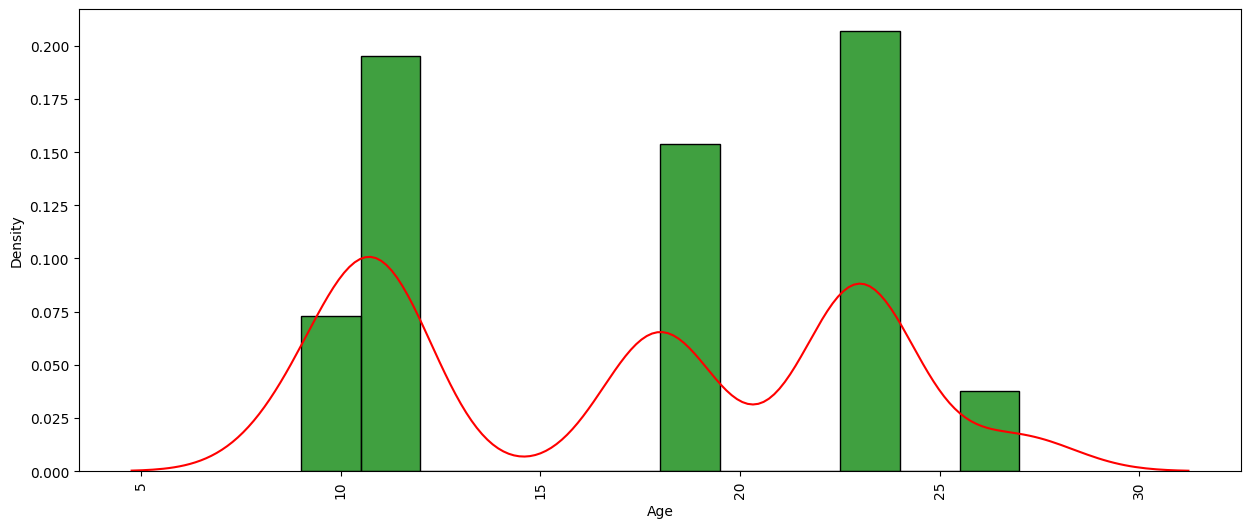

In [24]:
plt.figure(figsize=(15,6))
sns.histplot(data['Age'], stat ='density', color = 'green')
sns.kdeplot(data['Age'], color = 'red')
plt.xticks(rotation=90)
plt.show()

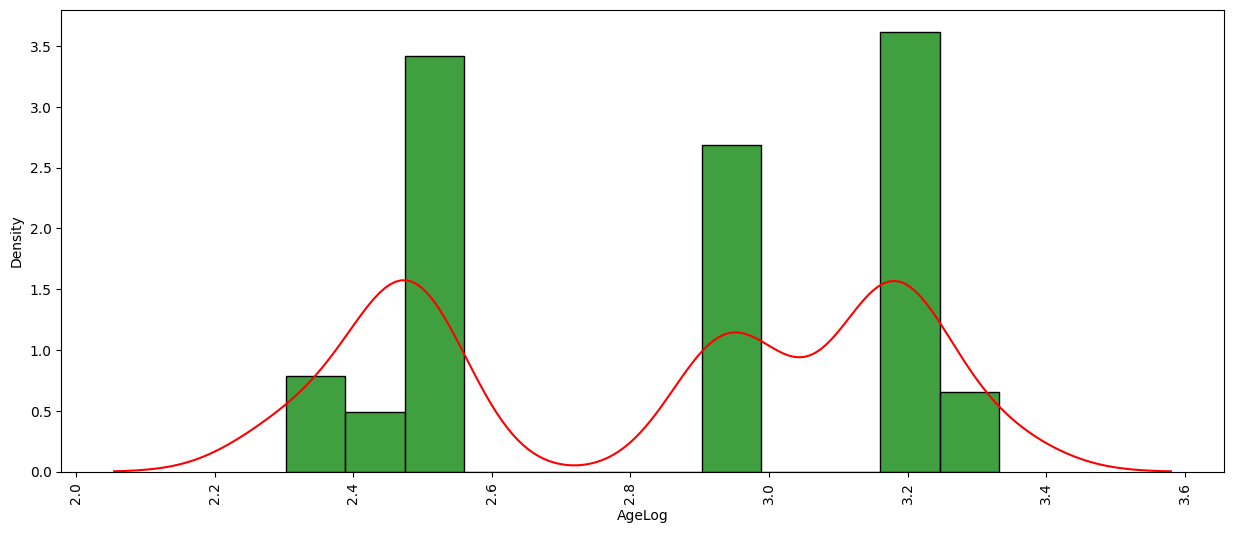

In [26]:
plt.figure(figsize=(15,6))
data['AgeLog'] = np.log(data['Age']+1)
sns.histplot(data['AgeLog'], stat ='density', color = 'green')
sns.kdeplot(data['AgeLog'], color = 'red')
plt.xticks(rotation=90)
plt.show()

In [37]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
FlexibilityLevel = le.fit_transform(data['Flexibility Level'])
data['Flexibility Level'] = FlexibilityLevel
categorical_features = ['Education Level','Gender','Institution Type', 'Device','IT Student','Location','Financial Condition', 'Internet Type', 'Network Type']

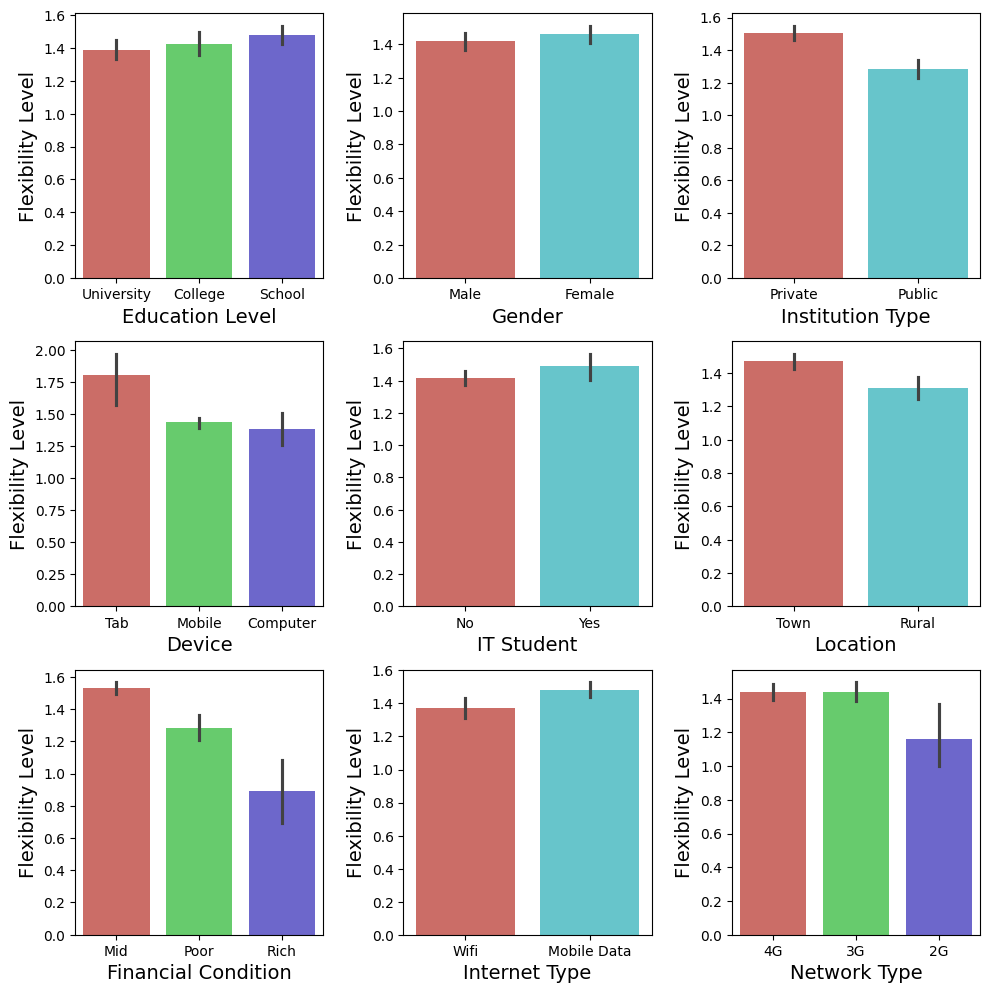

In [38]:
fig, axes = plt.subplots(3,3, figsize=[10,10])
axes = [ax for axes_row in axes for ax in axes_row]
target = 'Flexibility Level'
for i,c in enumerate(categorical_features):
  sns.barplot(x=data[c],y=data[target], ax=axes[i], palette='hls')
  axes[i].set_xlabel(c,fontsize=14)
  axes[i].set_ylabel('Flexibility Level', fontsize = 14)
plt.tight_layout()

In [39]:
EducationLevel = le.fit_transform(data['Education Level'])
Gender = le.fit_transform(data['Gender'])
InstitutionType = le.fit_transform(data['Institution Type'])
Device = le.fit_transform(data['Device'])
ITStudent = le.fit_transform(data['IT Student'])
Location = le.fit_transform(data['Location'])
FinancialCondition = le.fit_transform(data['Financial Condition'])
InternetType = le.fit_transform(data['Internet Type'])
le.fit_transform(data['Network Type'])
data['Education Level'] = EducationLevel
data['Gender'] = Gender
data['Institution Type'] = InstitutionType
data['Device'] = Device
data['IT Student'] = ITStudent
data['Location'] = Location
data['Financial Condition'] = FinancialCondition
data['Internet Type'] = InternetType


In [40]:
data.head()

,Education Level,Institution Type,Gender,Age,Device,IT Student,Location,Financial Condition,Internet Type,Network Type,Flexibility Level,AgeLog
0,2,0,1,23,2,0,1,0,1,4G,2,3.178054
1,2,0,0,23,1,0,1,0,0,4G,2,3.178054
2,0,1,0,18,1,0,1,0,1,4G,2,2.944439
3,1,0,0,11,1,0,1,0,0,4G,2,2.484907
4,1,0,0,18,1,0,1,1,0,3G,1,2.944439


In [41]:
data.tail()

,Education Level,Institution Type,Gender,Age,Device,IT Student,Location,Financial Condition,Internet Type,Network Type,Flexibility Level,AgeLog
1200,0,0,0,18,1,0,1,0,1,4G,1,2.944439
1201,0,0,0,18,1,0,0,0,1,4G,2,2.944439
1202,1,0,1,11,1,0,1,0,0,3G,2,2.484907
1203,0,0,0,18,1,0,0,0,1,4G,1,2.944439
1204,1,0,0,11,1,0,1,1,0,3G,2,2.484907


In [48]:
#X.shape
#y.shape
from sklearn.model_selection import train_test_split
#train_x,test_x,train_y,test_y = train_test_split(x,y,test_size=0.2,random_state=100)